In [3]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2461s 14us/step
Training Images: (50000, 32, 32, 3)
Testing Images: (10000, 32, 32, 3)


In [5]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

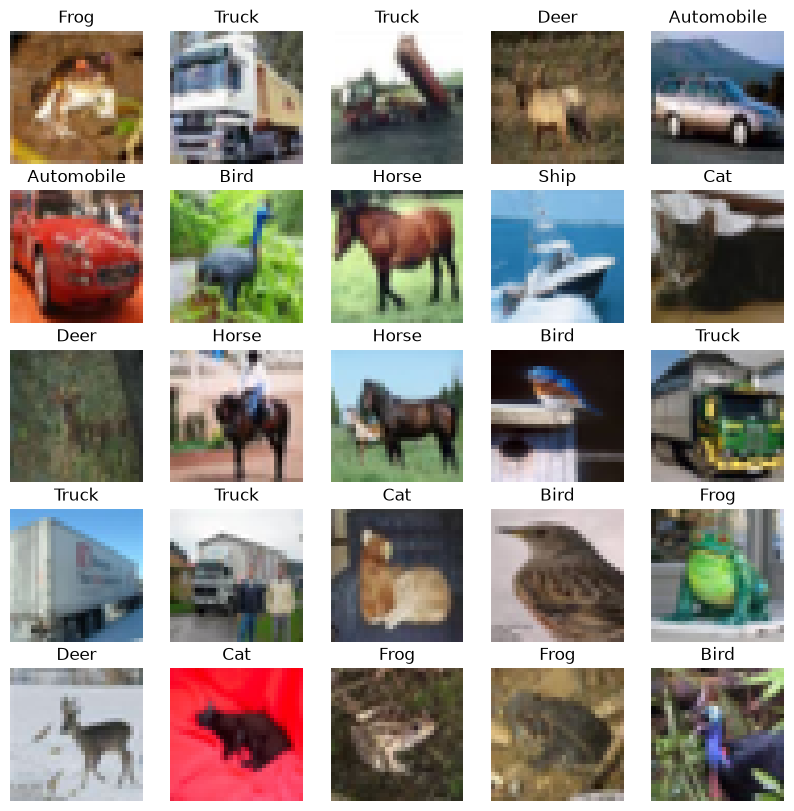

In [6]:
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

In [7]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [8]:
model = models.Sequential([
    
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    
    layers.Flatten(),
    
    layers.Dense(64, activation='relu'),
    
    layers.Dense(10, activation='softmax')
])

c:\Users\shris\OneDrive\Desktop\CIFAR10-Image-Classification-CNN\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.4335 - loss: 1.5518 - val_accuracy: 0.5421 - val_loss: 1.2764
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.5816 - loss: 1.1822 - val_accuracy: 0.6087 - val_loss: 1.1124
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.6363 - loss: 1.0393 - val_accuracy: 0.6427 - val_loss: 1.0295
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6686 - loss: 0.9459 - val_accuracy: 0.6531 - val_loss: 0.9929
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6973 - loss: 0.8680 - val_accuracy: 0.6702 - val_loss: 0.9611
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.7150 - loss: 0.8143 - val_accuracy: 0.6771 - val_loss: 0.9210
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7359 - loss: 0.7558 - val_accuracy: 0.6872 - val_loss: 0.9135
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7490 -

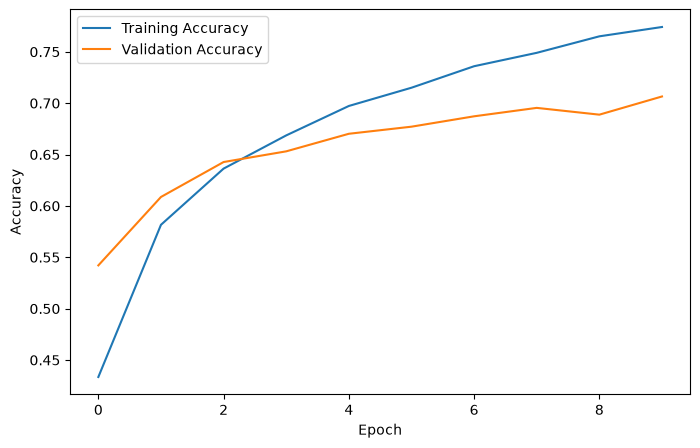

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [13]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7065 - loss: 0.8900
Test Accuracy: 0.7064999938011169


In [14]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [15]:
print(classification_report(y_test, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

    Airplane       0.72      0.76      0.74      1000
  Automobile       0.84      0.80      0.82      1000
        Bird       0.68      0.50      0.58      1000
         Cat       0.56      0.50      0.53      1000
        Deer       0.62      0.67      0.64      1000
         Dog       0.67      0.59      0.63      1000
        Frog       0.80      0.77      0.78      1000
       Horse       0.66      0.82      0.73      1000
        Ship       0.83      0.79      0.81      1000
       Truck       0.70      0.87      0.78      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.70     10000
weighted avg       0.71      0.71      0.70     10000



In [16]:
cm = confusion_matrix(y_test, y_pred_classes)

print(cm)

[[762  27  27  17  43   2   5  14  45  58]
 [ 24 795   9   5   2   1   7   2  18 137]
 [ 82   9 502  71 124  67  57  60  13  15]
 [ 28  10  55 500  91 137  53  74  23  29]
 [ 19   6  42  52 670  29  36 126  13   7]
 [ 17   3  39 142  54 591  24 102   9  19]
 [  9   6  45  55  49  24 769  18   9  16]
 [ 15   1  11  36  40  32   7 821   6  31]
 [ 80  37   8  12   8   2   2   7 788  56]
 [ 16  54   5   8   3   1   2  19  25 867]]


In [17]:
model.save("cnn_cifar10.keras")

Conclusion

• Successfully implemented a Convolutional Neural Network (CNN) for CIFAR-10 image classification.

• Preprocessed the dataset by normalizing pixel values.

• Built a CNN with convolutional, pooling, flatten, and dense layers.

• Trained the model using the Adam optimizer and sparse categorical cross-entropy loss.

• Evaluated the model on the test dataset and achieved good classification accuracy.

• Saved the trained model for future inference and deployment.